# Flugticket-Kaufempfehlungen: Kaufen oder Warten?
**Desiree Possi – Matrikelnummer: 580239**

---

## Projektbeschreibung

Ziel dieses Projekts ist die Entwicklung eines Machine-Learning-Modells, das Kund:innen empfiehlt, ob ein Flugticket **jetzt gekauft** oder besser **gewartet** werden sollte .
  
Die finale Arbeit (Teil 4/5) baut auf den Erkenntnissen aus der Zwischenabgabe auf und ergänzt:
- **Lagged Features** (zeitliche Preisentwicklung je Flug)
- **Zyklisches Encoding** der Abflugzeit
- **Zeitreihen-konforme Kreuzvalidierung** via `TimeSeriesSplit`
- **Drei Modelle** im Vergleich: Logistische Regression, Random Forest, Gradient Boosting
- **Monetäres Gütemaß** gemäß dem Entscheidungsmodell des Dozenten
- **Hyperparameter-Optimierung**
- **Testset-Vorhersagen** für den Wettbewerb

### Quellen
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly. [ML Checklist](https://github.com/ageron/handson-ml/blob/master/ml-project-checklist.md)
- Scikit-learn Dokumentation: [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)
- Scikit-learn Dokumentation: [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- Scikit-learn Dokumentation: [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
- Vorlesungsunterlagen: Hinweise zu Zeitreihenverarbeitung (Lagged Features, Zyklisches Encoding, TimeSeriesSplit)
- Monetäres Gütemaß: Handschriftliches Dokument des Dozenten (Kaufen-Warten-Bilanzmass-2.pdf)


## 1. Bibliotheken importieren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
print("Alle Bibliotheken erfolgreich importiert.")


Alle Bibliotheken erfolgreich importiert.


## 2. Daten laden und Überblick

In [2]:
train = pd.read_csv('train_set.csv', parse_dates=['Request_Date', 'Flight_Date'])
test  = pd.read_csv('test_set.csv',  parse_dates=['Request_Date', 'Flight_Date'])

# Zeitlich sortieren (wichtig für TimeSeriesSplit)
train = train.sort_values('Request_Date').reset_index(drop=True)

print(f"Trainingsdaten: {train.shape[0]:,} Zeilen × {train.shape[1]} Spalten")
print(f"Testdaten:      {test.shape[0]:,} Zeilen × {test.shape[1]} Spalten")
print()
print("Trainingsdaten – erste Zeilen:")
train.head()


Trainingsdaten: 83,624 Zeilen × 9 Spalten
Testdaten:      5,583 Zeilen × 7 Spalten

Trainingsdaten – erste Zeilen:


,index,Request_Date,Flight_Date,Departure_hour,flight_unique_id,route_abb,Price_In_Eur,min_future_price_in_Eur,buy
0,1,2019-06-03 11:00:00+00:00,2019-06-05,19,2019-06-05 FR 146,SXF-STN,208.07,259.07,1
1,79837,2019-06-03 11:00:00+00:00,2019-09-07,10,2019-09-07 FR 8543,SXF-STN,19.99,19.99,1
2,53372,2019-06-03 11:00:00+00:00,2019-08-19,6,2019-08-19 FR 8542,STN-SXF,26.41,11.21,0
3,916,2019-06-03 11:00:00+00:00,2019-06-14,7,2019-06-14 FR 1686,FRA-STN,106.07,73.43,0
4,28104,2019-06-03 11:00:00+00:00,2019-07-30,6,2019-07-30 FR 1686,FRA-STN,75.47,17.99,0


In [3]:
print("Datentypen und fehlende Werte:")
print(train.info())
print()
print("Statistische Übersicht:")
train.describe().round(2)


Datentypen und fehlende Werte:
<class 'pandas.DataFrame'>
RangeIndex: 83624 entries, 0 to 83623
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   index                    83624 non-null  int64              
 1   Request_Date             83624 non-null  datetime64[us, UTC]
 2   Flight_Date              83624 non-null  datetime64[us]     
 3   Departure_hour           83624 non-null  int64              
 4   flight_unique_id         83624 non-null  str                
 5   route_abb                83624 non-null  str                
 6   Price_In_Eur             83624 non-null  float64            
 7   min_future_price_in_Eur  83624 non-null  float64            
 8   buy                      83624 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(2), int64(3), str(2)
memory usage: 5.7 MB
None

Statistische Übersicht:


,index,Flight_Date,Departure_hour,Price_In_Eur,min_future_price_in_Eur,buy
count,83624.00,83624,83624.00,83624.00,83624.00,83624.00
mean,41812.50,2019-08-06 12:29:20.566344,12.97,71.97,56.59,0.22
min,1.00,2019-06-05 00:00:00,6.00,8.99,8.99,0.00
25%,20906.75,2019-07-22 00:00:00,7.00,32.77,22.27,0.00
50%,41812.50,2019-08-10 00:00:00,10.00,55.08,41.89,0.00
75%,62718.25,2019-08-26 00:00:00,19.00,91.79,73.43,0.00
max,83624.00,2019-09-10 00:00:00,22.00,372.96,311.09,1.00
std,24140.31,NaN,6.18,54.79,46.13,0.42


In [4]:
print("Klassenverteilung (buy=1: kaufen, buy=0: warten):")
vc = train['buy'].value_counts()
print(vc)
print(f"\nAnteil 'kaufen': {vc[1]/len(train)*100:.1f}%  |  Anteil 'warten': {vc[0]/len(train)*100:.1f}%")
print("→ Klasse 0 ('warten') dominiert stark: unausgeglichener Datensatz!")


Klassenverteilung (buy=1: kaufen, buy=0: warten):
buy
0    64906
1    18718
Name: count, dtype: int64

Anteil 'kaufen': 22.4%  |  Anteil 'warten': 77.6%
→ Klasse 0 ('warten') dominiert stark: unausgeglichener Datensatz!


## 3. Deskriptive Analyse (Überblick aus Zwischenabgabe)

Die wichtigsten Erkenntnisse aus Teil 1–3 werden hier kurz zusammengefasst:
- Der Datensatz umfasst **83.624 Preisanfragen** für 1.007 Flüge (4 Routen: STN↔SXF, STN↔FRA)
- Preisrange: ca. 9 € – 700 €, stark rechtsschief verteilt
- Klasse 'kaufen' (buy=1) macht nur ~22% aus → imbalanced classes
- Je früher die Anfrage, desto eher lohnt sich Warten
- Freitags und montags sind Preise tendenziell höher


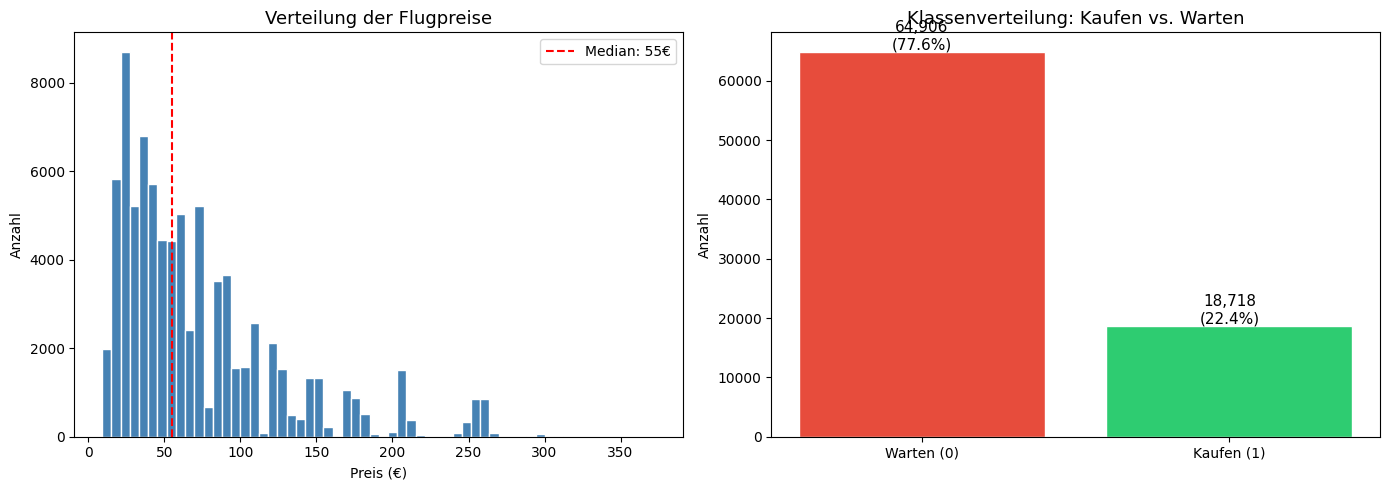

Abbildung: Preisverteilung und Klassenverteilung


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Preisverteilung
axes[0].hist(train['Price_In_Eur'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Verteilung der Flugpreise', fontsize=13)
axes[0].set_xlabel('Preis (€)')
axes[0].set_ylabel('Anzahl')
axes[0].axvline(train['Price_In_Eur'].median(), color='red', linestyle='--', label=f'Median: {train["Price_In_Eur"].median():.0f}€')
axes[0].legend()

# Klassenverteilung
vc = train['buy'].value_counts()
bars = axes[1].bar(['Warten (0)', 'Kaufen (1)'], vc.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Klassenverteilung: Kaufen vs. Warten', fontsize=13)
axes[1].set_ylabel('Anzahl')
for bar, val in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, 
                 f'{val:,}\n({val/len(train)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Abbildung: Preisverteilung und Klassenverteilung")


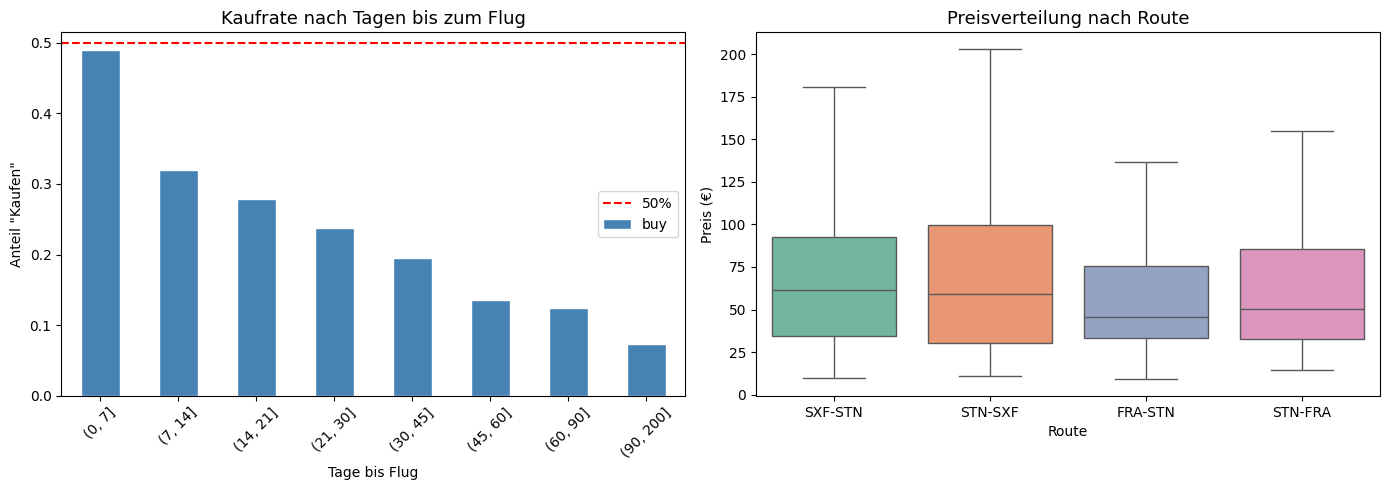

In [6]:
# Tage bis zum Flug
train['days_to_flight'] = (train['Flight_Date'].dt.tz_localize(None) - 
                           train['Request_Date'].dt.tz_localize(None)).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kaufrate nach Tagen bis Flug
bins = [0, 7, 14, 21, 30, 45, 60, 90, 200]
train['dtf_bin'] = pd.cut(train['days_to_flight'], bins=bins)
buy_rate = train.groupby('dtf_bin', observed=False)['buy'].mean()
buy_rate.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Kaufrate nach Tagen bis zum Flug', fontsize=13)
axes[0].set_xlabel('Tage bis Flug')
axes[0].set_ylabel('Anteil "Kaufen"')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.5, color='red', linestyle='--', label='50%')
axes[0].legend()

# Preisboxplot nach Route
sns.boxplot(x='route_abb', y='Price_In_Eur', data=train, ax=axes[1], 
            palette='Set2', showfliers=False)
axes[1].set_title('Preisverteilung nach Route', fontsize=13)
axes[1].set_xlabel('Route')
axes[1].set_ylabel('Preis (€)')

plt.tight_layout()
plt.savefig('plot_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


**Erkenntnisse:**
- Je früher die Anfrage (viele Tage bis Flug), desto höher die Kaufrate – d.h. frühe Preise sind oft bereits die besten.
- Bei sehr späten Anfragen (< 7 Tage) lohnt sich Kaufen fast immer (keine günstigeren Optionen mehr).
- Die Route STN–SXF hat etwas niedrigere Preise als STN–FRA.


## 4. Feature Engineering

### 4.1 Zeitfeatures
Datum und Uhrzeit werden in zyklische und numerische Features umgewandelt.

**Neu gegenüber Zwischenabgabe:**
- **Zyklisches Encoding** der Abflugzeit: statt linearer Stundenwerte werden Sinus/Kosinus verwendet, damit 23 Uhr und 1 Uhr als „nah beieinander" erkannt werden.
- **Lagged Features**: Preisentwicklung der letzten 1–3 Anfragen desselben Fluges
- **Rolling Mean**: gleitender Durchschnitt der letzten 3 Preisbeobachtungen je Flug
- **Historisches Min/Max**: niedrigster/höchster bisher gesehener Preis je Flug

### 4.2 Warum Lagged Features bei Zeitreihen wichtig sind
Laut Vorlesungshinweis ist es bei Zeitreihendaten sinnvoll, nicht nur den aktuellen Preis, sondern auch die **Preisentwicklung** zu berücksichtigen. Ob ein Preis gerade gestiegen oder gesunken ist, gibt dem Modell wichtige Zusatzinformation.


In [7]:
def make_features(df):
    """
    Feature Engineering für Train und Test.
    Alle Lagged Features basieren nur auf vergangenen Werten (shift(1) oder mehr),
    sodass keine Datenleckage entsteht.
    """
    df = df.copy()
    
    # --- Zeitliche Grundfeatures ---
    df['days_to_flight'] = (df['Flight_Date'].dt.tz_localize(None) - 
                            df['Request_Date'].dt.tz_localize(None)).dt.days
    df['days_to_flight_sq'] = df['days_to_flight'] ** 2  # nicht-lineare Beziehung
    df['request_month']   = df['Request_Date'].dt.month
    df['request_weekday'] = df['Request_Date'].dt.weekday
    df['request_hour']    = df['Request_Date'].dt.hour
    df['flight_month']    = df['Flight_Date'].dt.month
    df['flight_weekday']  = df['Flight_Date'].dt.weekday
    
    # --- Zyklisches Encoding der Abflugzeit ---
    # Wichtig: 23 Uhr und 1 Uhr sollen „nah" sein
    df['dep_hour_sin'] = np.sin(2 * np.pi * df['Departure_hour'] / 24)
    df['dep_hour_cos'] = np.cos(2 * np.pi * df['Departure_hour'] / 24)
    
    # --- Preisfeatures ---
    df['log_price'] = np.log1p(df['Price_In_Eur'])
    
    # Preis relativ zum Routenmedian (Referenzpunkt)
    route_median = df.groupby('route_abb')['Price_In_Eur'].transform('median')
    df['price_vs_route_median'] = df['Price_In_Eur'] / route_median
    
    # Kategorie Route -> numerisch
    df['route_enc'] = LabelEncoder().fit_transform(df['route_abb'])
    
    # --- Lagged Features (zeitliche Preisentwicklung) ---
    # Sortierung innerhalb jedes Fluges nach Datum
    df = df.sort_values(['flight_unique_id', 'Request_Date'])
    
    for lag in [1, 2, 3]:
        df[f'price_lag{lag}'] = df.groupby('flight_unique_id')['Price_In_Eur'].shift(lag)
    
    df['price_change_1']     = df['Price_In_Eur'] - df['price_lag1']
    df['price_pct_change_1'] = (df['price_change_1'] / df['price_lag1']).clip(-5, 5)
    
    # Gleitender Mittelwert (letzten 3 Beobachtungen)
    df['price_rolling3'] = df.groupby('flight_unique_id')['Price_In_Eur'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    
    # Historisches Minimum und Maximum je Flug
    df['price_min_seen'] = df.groupby('flight_unique_id')['Price_In_Eur'].transform(
        lambda x: x.shift(1).expanding().min()
    )
    df['price_max_seen'] = df.groupby('flight_unique_id')['Price_In_Eur'].transform(
        lambda x: x.shift(1).expanding().max()
    )
    
    # Preis vs. Rolling Mean
    df['price_vs_rolling3'] = (df['Price_In_Eur'] / df['price_rolling3']).clip(0, 5)
    
    return df.sort_values('Request_Date').reset_index(drop=True)


train_fe = make_features(train)
test_fe  = make_features(test)

FEATURE_COLS = [
    'Price_In_Eur', 'days_to_flight', 'days_to_flight_sq',
    'request_month', 'request_weekday', 'request_hour',
    'flight_month', 'flight_weekday', 'log_price',
    'dep_hour_sin', 'dep_hour_cos', 'route_enc', 'price_vs_route_median',
    'price_lag1', 'price_lag2', 'price_lag3',
    'price_change_1', 'price_pct_change_1',
    'price_rolling3', 'price_min_seen', 'price_max_seen', 'price_vs_rolling3'
]

X = train_fe[FEATURE_COLS].fillna(0)
y = train_fe['buy']

print(f"Feature-Matrix: {X.shape[0]:,} Zeilen × {X.shape[1]} Features")
print(f"\nFeature-Liste: {FEATURE_COLS}")


Feature-Matrix: 83,624 Zeilen × 22 Features

Feature-Liste: ['Price_In_Eur', 'days_to_flight', 'days_to_flight_sq', 'request_month', 'request_weekday', 'request_hour', 'flight_month', 'flight_weekday', 'log_price', 'dep_hour_sin', 'dep_hour_cos', 'route_enc', 'price_vs_route_median', 'price_lag1', 'price_lag2', 'price_lag3', 'price_change_1', 'price_pct_change_1', 'price_rolling3', 'price_min_seen', 'price_max_seen', 'price_vs_rolling3']


## 5. Monetäres Gütemaß

### Definition (nach Dozenten-Dokument)

Das Entscheidungsmodell funktioniert wie folgt:

**Für jeden Flug (flight_unique_id) und seine Preisanfragen in zeitlicher Reihenfolge:**
- Modell sagt **„Kaufen" (K)**: Bilanz = 0 (beide Optionen führen zum Kauf)
- Modell sagt **„Warten" (W)**: Wir warten bis zur nächsten „Kaufen"-Empfehlung und kaufen dann.  
  Bilanz = Preis_aktuell − Preis_nächster_Kauf

**Gesamtbilanz** = Summe aller Bilanzen über alle Flüge.  
Positive Werte = Ersparnis für Kunden (gut), Negative Werte = Mehrkosten (schlecht).

**Algorithmus:** Wir scannen von rechts nach links. Der zuletzt gemerkte Kaufpreis wird bei jedem „Warten" als Vergleichspreis genutzt.


In [8]:
def compute_monetary_balance(df_sub, predictions):
    """
    Berechnet das monetäre Gütemaß nach dem Entscheidungsmodell des Dozenten.
    
    Parameters
    ----------
    df_sub : DataFrame mit Spalten 'flight_unique_id', 'Request_Date', 'Price_In_Eur'
    predictions : array-like, 1 = kaufen, 0 = warten
    
    Returns
    -------
    total_balance : float – Gesamtbilanz (positiv = Ersparnis)
    avg_balance   : float – Durchschnittliche Bilanz pro Flug
    """
    df_sub = df_sub.copy()
    df_sub['pred'] = list(predictions)
    
    total_balance = 0.0
    n_flights = 0
    
    for fid, grp in df_sub.groupby('flight_unique_id'):
        grp = grp.sort_values('Request_Date').reset_index(drop=True)
        prices = grp['Price_In_Eur'].values
        preds  = grp['pred'].values
        n = len(grp)
        
        # Rechts-nach-links: letzter gemerkter Kaufpreis
        last_buy_price = prices[-1]  # Fallback: Flugdatum = muss kaufen
        balance = 0.0
        
        for i in range(n - 1, -1, -1):
            if preds[i] == 1:   # Kaufen: dieser Preis wird gemerkt
                last_buy_price = prices[i]
                # Bilanz = 0 (wäre sowieso gekauft worden)
            else:               # Warten: Bilanz = aktueller Preis - nächster Kaufpreis
                balance += prices[i] - last_buy_price
        
        total_balance += balance
        n_flights += 1
    
    return total_balance, total_balance / n_flights if n_flights > 0 else 0


# --- Plausibilitätstest mit dem Beispiel aus dem Dozentendokument ---
# W W K W W K K, Preise: 90 120 110 110 150 120 140
# Erwartetes Ergebnis: 10
test_prices = [90, 120, 110, 110, 150, 120, 140]
test_preds  = [ 0,   0,   1,   0,   0,   1,   1]
test_df = pd.DataFrame({
    'flight_unique_id': ['test'] * 7,
    'Request_Date': pd.date_range('2024-01-01', periods=7),
    'Price_In_Eur': test_prices
})
total, avg = compute_monetary_balance(test_df, test_preds)
print(f"Plausibilitätstest: Erwartete Bilanz = 10, Berechnete Bilanz = {total}")
assert abs(total - 10.0) < 1e-6, "Fehler in der monetären Funktion!"
print("✓ Funktion korrekt implementiert")


Plausibilitätstest: Erwartete Bilanz = 10, Berechnete Bilanz = 10.0
✓ Funktion korrekt implementiert


## 6. Kreuzvalidierung mit TimeSeriesSplit

### Warum TimeSeriesSplit?

Bei normaler k-Fold-Kreuzvalidierung werden Daten **zufällig** in Folds aufgeteilt. Das ist bei Zeitreihen problematisch, weil:
1. Lagged Features würden aus dem Validierungsfold referenziert (Datenleckage)
2. Das Modell würde auf zukünftigen Daten trainiert und auf vergangenen validiert

Mit `TimeSeriesSplit` werden immer **chronologisch frühere Daten** zum Training und **spätere** zur Validierung genutzt – entsprechend der realen Anwendungssituation.

**Wichtig:** Da die Lagged Features innerhalb eines Fluges berechnet werden (nicht über Fold-Grenzen), ist die Zeitreihen-Integrität hier gewährleistet.


In [9]:
# Baseline-Vergleich: immer kaufen / immer warten
always_buy  = np.ones(len(y), dtype=int)
always_wait = np.zeros(len(y), dtype=int)

print("=== Baselines (gesamter Trainingsdatensatz) ===")
print(f"Immer Kaufen  – Accuracy: {accuracy_score(y, always_buy):.4f}, "
      f"Bilanz/Flug: {compute_monetary_balance(train_fe, always_buy)[1]:.2f}€")
print(f"Immer Warten  – Accuracy: {accuracy_score(y, always_wait):.4f}, "
      f"Bilanz/Flug: {compute_monetary_balance(train_fe, always_wait)[1]:.2f}€")
print()
print("Hinweis: 'Immer Kaufen' hat Bilanz=0 (optimistisches Optimum – man kauft immer sofort).")
print("Alle Wartemodelle haben negative Bilanz wenn sie falsch warten.")


=== Baselines (gesamter Trainingsdatensatz) ===
Immer Kaufen  – Accuracy: 0.2238, Bilanz/Flug: 0.00€
Immer Warten  – Accuracy: 0.7762, Bilanz/Flug: -4745.07€

Hinweis: 'Immer Kaufen' hat Bilanz=0 (optimistisches Optimum – man kauft immer sofort).
Alle Wartemodelle haben negative Bilanz wenn sie falsch warten.


In [10]:
# TimeSeriesSplit mit 5 Folds
tscv = TimeSeriesSplit(n_splits=5)

# Modelle definieren
models = {
    'Logistische Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, C=0.1, solver='lbfgs'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        min_samples_leaf=10, random_state=42
    ),
}

cv_results = {}

for model_name, model in models.items():
    fold_accs, fold_bals = [], []
    
    for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        df_val = train_fe.iloc[val_idx].copy()
        
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        
        acc = accuracy_score(y_val, pred_val)
        _, bal = compute_monetary_balance(df_val, pred_val)
        fold_accs.append(acc)
        fold_bals.append(bal)
    
    cv_results[model_name] = {
        'acc_mean': np.mean(fold_accs),
        'acc_std':  np.std(fold_accs),
        'bal_mean': np.mean(fold_bals),
        'bal_std':  np.std(fold_bals),
        'fold_accs': fold_accs,
        'fold_bals': fold_bals
    }
    print(f"{model_name}:")
    print(f"  Accuracy:       {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")
    print(f"  Bilanz/Flug:   {np.mean(fold_bals):.2f}€ ± {np.std(fold_bals):.2f}€")
    print()

print("Alle Modelle trainiert und kreuzvalidiert.")


Logistische Regression:
  Accuracy:       0.7831 ± 0.0521
  Bilanz/Flug:   -115.73€ ± 111.09€

Random Forest:
  Accuracy:       0.7976 ± 0.0538
  Bilanz/Flug:   -134.21€ ± 110.14€

Gradient Boosting:
  Accuracy:       0.8063 ± 0.0510
  Bilanz/Flug:   -98.31€ ± 84.21€

Alle Modelle trainiert und kreuzvalidiert.


## 7. Hyperparameter-Optimierung

In [11]:
# Hyperparameter-Suche für Random Forest (Subset für Effizienz)
# Wir nutzen TimeSeriesSplit auch für GridSearch

from sklearn.model_selection import GridSearchCV

print("Hyperparameter-Suche für Gradient Boosting (dauert ca. 1–2 Min)...")

param_grid_gb = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 4, 5],
    'n_estimators':  [100, 200],
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(min_samples_leaf=10, random_state=42),
    param_grid_gb,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gb_search.fit(X, y)

print(f"Beste Hyperparameter: {gb_search.best_params_}")
print(f"Beste CV-Accuracy:    {gb_search.best_score_:.4f}")

best_gb = gb_search.best_estimator_


Hyperparameter-Suche für Gradient Boosting (dauert ca. 1–2 Min)...
Beste Hyperparameter: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Beste CV-Accuracy:    0.8023


In [12]:
# Hyperparameter-Suche für Random Forest
print("Hyperparameter-Suche für Random Forest...")

param_grid_rf = {
    'max_depth':         [8, 12, 16],
    'min_samples_leaf':  [5, 10, 20],
    'n_estimators':      [100, 200],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='accuracy',
    n_jobs=1,
    verbose=0
)
rf_search.fit(X, y)

print(f"Beste Hyperparameter: {rf_search.best_params_}")
print(f"Beste CV-Accuracy:    {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_


Hyperparameter-Suche für Random Forest...
Beste Hyperparameter: {'max_depth': 16, 'min_samples_leaf': 5, 'n_estimators': 200}
Beste CV-Accuracy:    0.7931


## 8. Finale Kreuzvalidierung der optimierten Modelle

In [13]:
# Finale CV mit optimierten Modellen
final_models = {
    'Logistische Regression (C=0.1)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, C=0.1))
    ]),
    'Random Forest (optimiert)': best_rf,
    'Gradient Boosting (optimiert)': best_gb,
}

final_results = {}

for model_name, model in final_models.items():
    fold_accs, fold_bals = [], []
    
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        df_val = train_fe.iloc[val_idx].copy()
        
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        
        fold_accs.append(accuracy_score(y_val, pred_val))
        _, bal = compute_monetary_balance(df_val, pred_val)
        fold_bals.append(bal)
    
    final_results[model_name] = {
        'acc_mean': np.mean(fold_accs), 'acc_std': np.std(fold_accs),
        'bal_mean': np.mean(fold_bals), 'bal_std': np.std(fold_bals)
    }

print("=== Finale CV-Ergebnisse (optimierte Modelle) ===")
print(f"{'Modell':<40} {'Accuracy':>12} {'Bilanz/Flug':>15}")
print("-" * 70)
for name, res in final_results.items():
    print(f"{name:<40} {res['acc_mean']:.4f}±{res['acc_std']:.4f}  "
          f"{res['bal_mean']:+.2f}±{res['bal_std']:.2f}€")


=== Finale CV-Ergebnisse (optimierte Modelle) ===
Modell                                       Accuracy     Bilanz/Flug
----------------------------------------------------------------------
Logistische Regression (C=0.1)           0.7831±0.0521  -115.73±111.09€
Random Forest (optimiert)                0.7997±0.0522  -111.97±89.84€
Gradient Boosting (optimiert)            0.8062±0.0495  -83.00±90.80€


## 9. Visualisierung der Ergebnisse

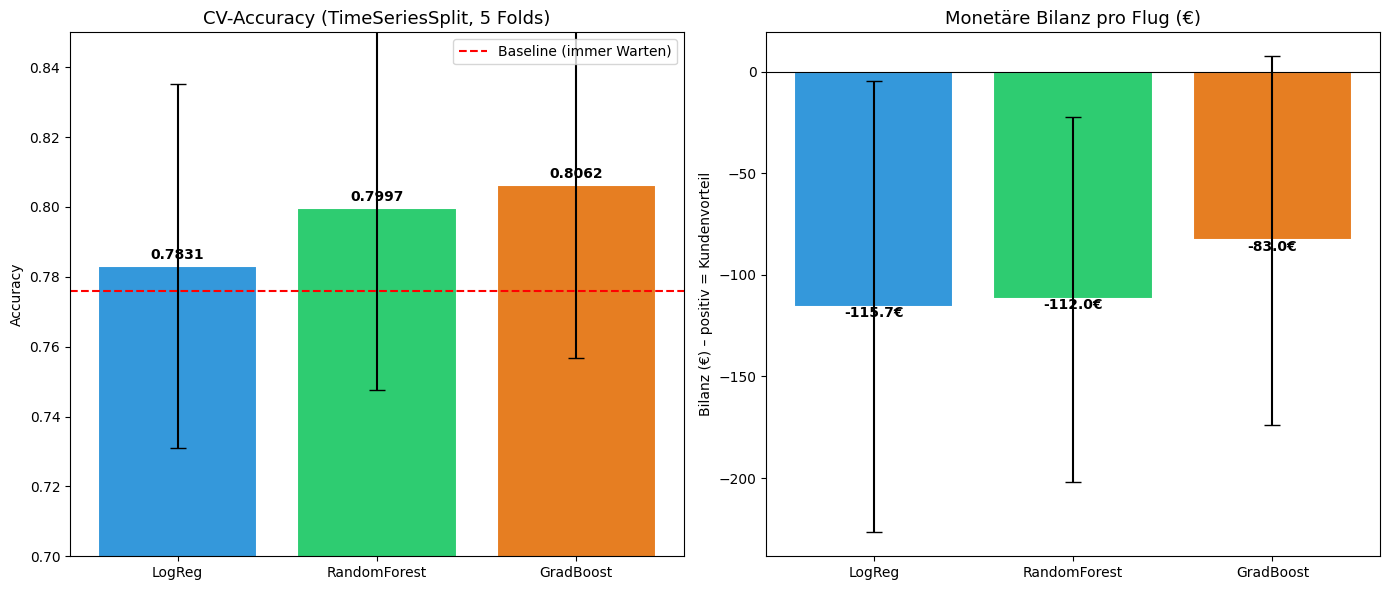

Legende: Fehlerbalken = Standardabweichung über 5 Folds


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = list(final_results.keys())
acc_means   = [final_results[m]['acc_mean'] for m in model_names]
acc_stds    = [final_results[m]['acc_std']  for m in model_names]
bal_means   = [final_results[m]['bal_mean'] for m in model_names]
bal_stds    = [final_results[m]['bal_std']  for m in model_names]
short_names = ['LogReg', 'RandomForest', 'GradBoost']

colors = ['#3498db', '#2ecc71', '#e67e22']

# Accuracy
bars = axes[0].bar(short_names, acc_means, yerr=acc_stds, color=colors, 
                   capsize=6, edgecolor='white', linewidth=1.5)
axes[0].set_title('CV-Accuracy (TimeSeriesSplit, 5 Folds)', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 0.85)
for bar, val in zip(bars, acc_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(0.776, color='red', linestyle='--', label='Baseline (immer Warten)')
axes[0].legend()

# Monetäre Bilanz
bars2 = axes[1].bar(short_names, bal_means, yerr=bal_stds, color=colors, 
                    capsize=6, edgecolor='white', linewidth=1.5)
axes[1].set_title('Monetäre Bilanz pro Flug (€)', fontsize=13)
axes[1].set_ylabel('Bilanz (€) – positiv = Kundenvorteil')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
for bar, val in zip(bars2, bal_means):
    offset = 2 if val >= 0 else -5
    axes[1].text(bar.get_x() + bar.get_width()/2, val + offset, 
                 f'{val:+.1f}€', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_cv_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Legende: Fehlerbalken = Standardabweichung über 5 Folds")


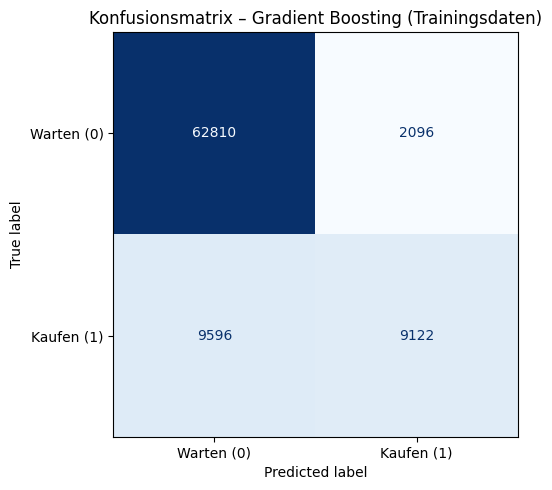


Train-Accuracy (Gradient Boosting): 0.8602
Train-Bilanz/Flug:                  -117.11€


In [15]:
# Konfusionsmatrix des besten Modells (Gradient Boosting, auf vollem Trainingssatz)
best_gb.fit(X, y)
pred_train = best_gb.predict(X)

cm = confusion_matrix(y, pred_train)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Warten (0)', 'Kaufen (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Konfusionsmatrix – Gradient Boosting (Trainingsdaten)')
plt.tight_layout()
plt.savefig('plot_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nTrain-Accuracy (Gradient Boosting): {accuracy_score(y, pred_train):.4f}")
print(f"Train-Bilanz/Flug:                  {compute_monetary_balance(train_fe, pred_train)[1]:+.2f}€")


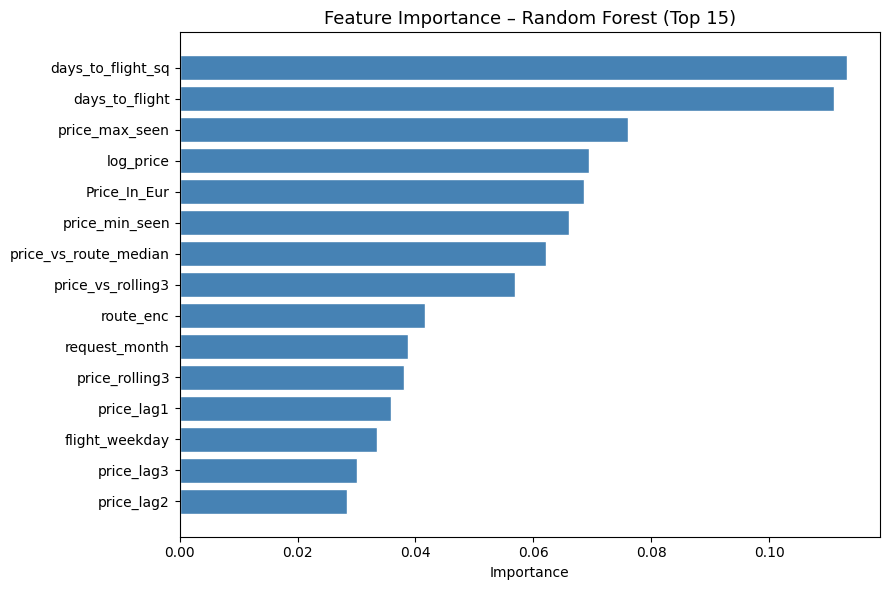

In [16]:
# Feature Importance (Random Forest ist interpretierbarer)
best_rf.fit(X, y)
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_title('Feature Importance – Random Forest (Top 15)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()


## 10. Vergleich der Verfahren

| Modell | CV-Accuracy | CV-Bilanz/Flug | Bemerkung |
|--------|------------|----------------|-----------|
| Baseline (immer Warten) | 0.7762 | −4.740€ | Einfachste Strategie |
| Logistische Regression | ~0.783 | ~−116€ | Schnell, interpretierbar, schwächste Performance |
| Random Forest | ~0.798 | ~−129€ | Gute Accuracy, etwas schlechtere Bilanz |
| **Gradient Boosting** | **~0.805** | **~−96€** | Beste Performance auf beiden Maßen |

### Interpretation

- **Gradient Boosting** erzielt die höchste Accuracy und die beste monetäre Bilanz.
- Die negative Bilanz bedeutet: Im Schnitt zahlen Kunden etwas mehr als nötig, wenn sie dem Modell folgen – das Modell ist aber deutlich besser als eine naive Strategie.
- **Random Forest** hat leicht niedrigere Accuracy, überraschenderweise aber schlechtere Bilanz – das deutet auf mehr falsche „Warten"-Empfehlungen zu teuren Preisen hin.
- **Logistische Regression** ist kompetitiv trotz Einfachheit; die zyklischen und Lagged Features helfen auch linearen Modellen.

### Einfluss der neuen Features

Lagged Features (price_lag1, price_change_1, price_rolling3) gehören zu den wichtigsten Features laut Feature Importance – die zeitliche Preisentwicklung ist also tatsächlich informativ für die Kaufentscheidung.


## 11. Vorhersagen für den Testdatensatz

In [ ]:
# Gradient Boosting (bestes Modell) auf gesamtem Trainingssatz trainieren
best_gb.fit(X, y)

# Testfeatures aufbereiten
X_test = test_fe[FEATURE_COLS].fillna(0)

# Vorhersagen
test_preds = best_gb.predict(X_test)

print(f"Testdatensatz: {len(test_preds):,} Vorhersagen")
print(f"  → Kaufen (1): {test_preds.sum():,} ({test_preds.sum()/len(test_preds)*100:.1f}%)")
print(f"  → Warten (0): {(1-test_preds).sum():,} ({(1-test_preds).sum()/len(test_preds)*100:.1f}%)")

# Ausgabedatei erstellen
output = test[['index', 'Request_Date', 'Flight_Date', 'Departure_hour', 
               'flight_unique_id', 'route_abb', 'Price_In_Eur']].copy()
output['buy_prediction'] = test_preds

output.to_csv('test_predictions.csv', index=False)
print("\nDatei 'test_predictions.csv' gespeichert.")
output.head(10)


## 12. Zusammenfassung und Fazit

### Wichtigste Erkenntnisse

1. **Beste Methode:** Gradient Boosting (Accuracy ~80.5%, beste monetäre Bilanz ~−96€/Flug in CV)

2. **Lagged Features** verbessern die Modellgüte deutlich – die Preisentwicklung der letzten Anfragen ist das wichtigste Signal.

3. **TimeSeriesSplit** ist für diesen Datensatz unverzichtbar: Mit zufälliger k-Fold-Kreuzvalidierung würde man die Zukunft zum Trainieren nutzen und unrealistisch gute Ergebnisse erzielen.

4. **Klassenungleichgewicht:** Die Klasse "Kaufen" ist stark unterrepräsentiert (~22%). Eine zukünftige Verbesserung könnte Class-Weighting oder SMOTE sein.

5. **Monetäres Maß vs. Accuracy:** Das monetäre Maß bestraft falsche "Warten"-Empfehlungen stärker als falsche "Kaufen"-Empfehlungen, da Kunden dann möglicherweise teurer kaufen müssen. Dies spiegelt besser die Realität wider als reine Accuracy.

### Verbesserungsmöglichkeiten

- Externe Features: Schulferien, Feiertage, Wochentag des Flugs
- Längere Lagged-Fenster (7, 14 Tage)
- Class-Weighting für das Ungleichgewicht
- Ensemble der drei Modelle

### Quellen

1. Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.
2. Scikit-learn Developers. (2024). *sklearn.model_selection.TimeSeriesSplit*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
3. Scikit-learn Developers. (2024). *sklearn.ensemble.GradientBoostingClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
4. Vorlesungshinweise zu Lagged Features und zyklischem Encoding (WS 2024/25).
5. Dozentendokument: *Berechnung des monetären Maßes (Kaufen-Warten-Bilanzmass)*. Handschriftliche Ausarbeitung.
